In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import hist
import vector
import pandas as pd

from physics.simulation import mcfm
from physics.analysis import zz2l2v, wwlvlv

In [2]:
# events = mcfm.from_csv('data/zz2l2v/qqWW/events_*.csv', n_rows=100_000)
events = mcfm.from_csv('data/zz2l2v/qqZZ/events_*.csv', n_rows=100_000)

In [3]:
# events_analyzed = wwlvlv.analyze(events)
events_analyzed = zz2l2v.analyze(events)

Inclusive | 1.0000000636681488
lepton (pT, eta) cuts | 0.9897326701170437
MET cut | 0.34571582588130445
mTZZ cut | 0.177448486590932
mZ window cut | 0.16891810724518222
DPhillMET cut | 0.16891810724518222
DRll cut | 0.15365251556469198


In [4]:
from physics.constants import mZ
mZsq = mZ**2

g1 = vector.array({'px': events.kinematics['p1_px'], 'py': events.kinematics['p1_py'], 'pz': events.kinematics['p1_pz'], 'E': events.kinematics['p1_E']})
g2 = vector.array({'px': events.kinematics['p2_px'], 'py': events.kinematics['p2_py'], 'pz': events.kinematics['p2_pz'], 'E': events.kinematics['p2_E']})

v1 = vector.array({'px': events.kinematics['p3_px'], 'py': events.kinematics['p3_py'], 'pz': events.kinematics['p3_pz'], 'E': events.kinematics['p3_E']})
l1 = vector.array({'px': events.kinematics['p4_px'], 'py': events.kinematics['p4_py'], 'pz': events.kinematics['p4_pz'], 'E': events.kinematics['p4_E']})
l2 = vector.array({'px': events.kinematics['p5_px'], 'py': events.kinematics['p5_py'], 'pz': events.kinematics['p5_pz'], 'E': events.kinematics['p5_E']})
v2 = vector.array({'px': events.kinematics['p6_px'], 'py': events.kinematics['p6_py'], 'pz': events.kinematics['p6_pz'], 'E': events.kinematics['p6_E']})

pt = np.array([l1.pt, l2.pt]).T
indices = np.argsort(pt, axis=1)[:,::-1]
leptons = np.asarray([l1, l2]).T
leptons_sorted = vector.array(np.take_along_axis(leptons, indices, axis=1), dtype=[("px", np.float32), ("py", np.float32), ("pz", np.float32), ("E", np.float32)])

results = {'l1_pt': leptons_sorted[:,0].pt, 'l1_eta': leptons_sorted[:,0].eta, 'l1_phi': leptons_sorted[:,0].phi, 'l1_energy': leptons_sorted[:,0].energy,
        'l2_pt': leptons_sorted[:,1].pt, 'l2_eta': leptons_sorted[:,1].eta, 'l2_phi': leptons_sorted[:,1].phi, 'l2_energy': leptons_sorted[:,1].energy}

l1 = leptons_sorted[:,0]
l2 = leptons_sorted[:,1]

ll = l1+l2
met = (v1+v2).to_2D()

In [5]:
llvv = l1+l2+v1+v2
zz_mt = np.sqrt( (np.sqrt(mZ**2 + ll.to_2D().pt2) + np.sqrt(mZ**2 + met.pt2))**2 - (ll.to_2D() + met).pt2 )

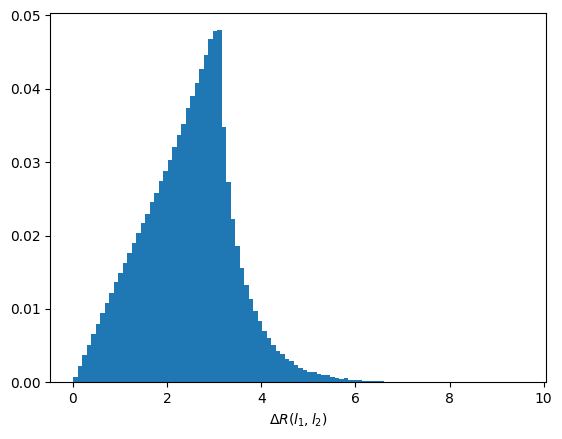

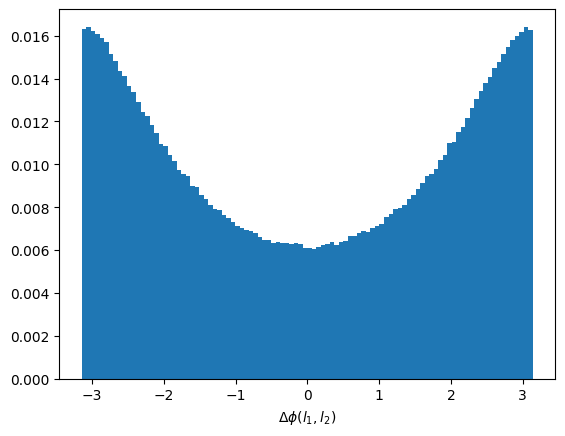

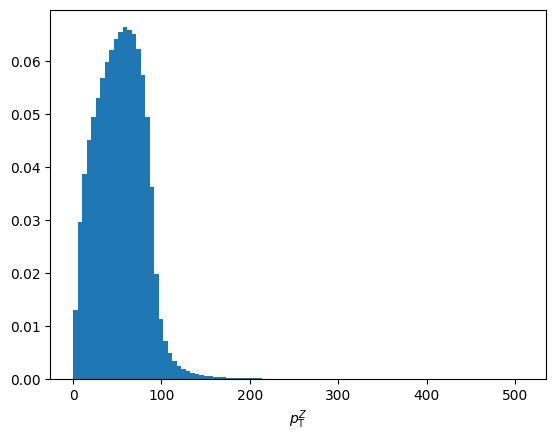

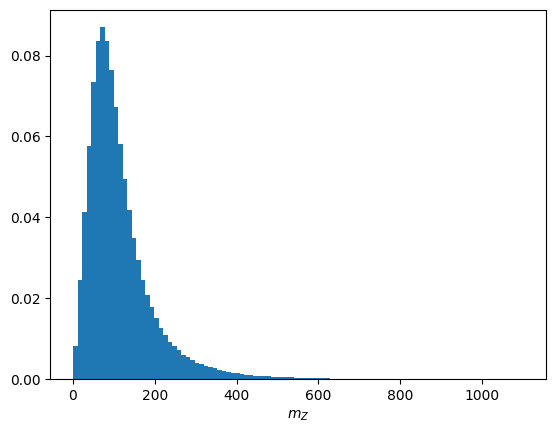

In [6]:
Z = (l1+l2)

plt.hist(l1.deltaR(l2), weights = events.weights, bins=100)
plt.xlabel('$\\Delta R(l_1, l_2)$')
plt.show()

plt.hist(l1.deltaphi(l2), weights = events.weights, bins=100)
plt.xlabel('$\\Delta \\phi(l_1, l_2)$')
plt.show()

plt.hist(Z.pt, weights = events.weights, bins=100)
plt.xlabel('$p_{\\mathrm{T}}^{Z}$')
plt.show()

plt.hist(Z.mass, weights = events.weights, bins=100)
plt.xlabel('$m_{Z}$')
# plt.xlim(70,110)
plt.show()

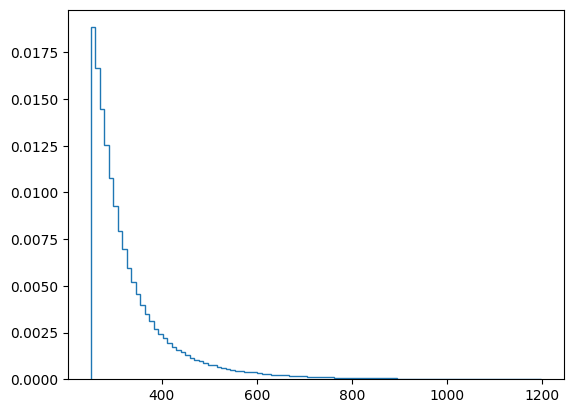

In [7]:
plt.hist(events_analyzed.kinematics['zz_mt'], weights=events_analyzed.weights, bins=100, histtype='step')
plt.show()